# Import Libraries and Astronomix Components

Set up JAX, Matplotlib, Astronomix geometry constants, simulation configuration, helper utilities, time integration, and the shock finder implementation.

In [11]:
import jax.numpy as jnp

import matplotlib.pyplot as plt

from astronomix import SPHERICAL, CARTESIAN
from astronomix import SimulationConfig
from astronomix import SimulationParams
from astronomix import get_helper_data
from astronomix import finalize_config
from astronomix import get_registered_variables
from astronomix import construct_primitive_state
from astronomix._physics_modules._shock_finder.shock_finder import find_shocks_pfrommer
from astronomix import time_integration
from astronomix.option_classes.simulation_config import DOUBLE_MINMOD, HLL, HLLC, MINMOD, OSHER, SUPERBEE

# Define Simulation Configuration

Create the simulation setup with Cartesian geometry, grid size, box size, limiter choice, and Riemann solver settings, then define the target end time.

In [12]:
limiter = MINMOD
num_cells = 501
box_size = 1.0
config = SimulationConfig(
    geometry=CARTESIAN,
    first_order_fallback=False,
    riemann_solver=HLLC,
    limiter=limiter,
    box_size=box_size,
    num_cells=num_cells,
)
params = SimulationParams(
    t_end=0.2,
)
box_size = 1.0
helper_data = get_helper_data(config)
registered_variables = get_registered_variables(config)

# Build 1D Shock Tube Initial Conditions

Construct the spatial grid and initialize density, velocity, and pressure as a left-right shock tube state with a discontinuity at the shock position.

In [13]:
shock_pos = 0.5
r = helper_data.geometric_centers
rho = jnp.where(r < shock_pos, 1.0, 0.125)
u = jnp.zeros_like(r)
p = jnp.where(r < shock_pos, 1.0, 0.1)

# Finalize Configuration and Run Time Integration

Create the primitive state, finalize the configuration using the state shape, and evolve the system with time integration to obtain the final fluid state.

In [14]:
initial_state = construct_primitive_state(
    config=config,
    registered_variables=registered_variables,
    density=rho,
    velocity_x=u,
    gas_pressure=p,
)
config = finalize_config(config, initial_state.shape)

final_state = time_integration(initial_state, config, params, registered_variables)
rho_final = final_state[registered_variables.density_index]
u_final = final_state[registered_variables.velocity_index]
p_final = final_state[registered_variables.pressure_index]
pressure = final_state[registered_variables.pressure_index]

Automatically setting open boundaries for Cartesian geometry.


# Run the Shock Finder

Apply the shock finder to the final state using the configuration, registered variables, and helper data to obtain shock surfaces, zones, directions, and Mach numbers.

In [15]:
new_result = find_shocks_pfrommer(
    final_state,
    config,
    registered_variables,
    helper_data,
)

# Inspect Shock Finder Output Types and Masks

Print the data types of the returned shock-finder arrays and extract the indices of shock surface cells and shock-zone cells for verification.

In [16]:
print("final_state:", type(final_state))
print("config:", type(config))
print("registered_variables:", type(registered_variables))
print("helper_data:", type(helper_data))
print(new_result.shock_surface_cells.dtype)
print(new_result.shock_zones.dtype)
print(new_result.shock_ids.dtype)
print(new_result.shock_zone_ids.dtype)
print(new_result.shock_direction.dtype)
print(new_result.mach_numbers.dtype)

new_surface_idx = jnp.where(new_result.shock_surface_cells)[0]
new_zone_idx = jnp.where(new_result.shock_zones)[0]

print("New shock surface indices:", new_surface_idx)
print("New shock zone cell count:", new_zone_idx.size)
print("New shock surface count:", jnp.sum(new_result.shock_surface_cells))
print("New Mach numbers at surface:", new_result.mach_numbers[new_result.shock_surface_cells])

final_state: <class 'jaxlib._jax.ArrayImpl'>
config: <class 'astronomix.option_classes.simulation_config.SimulationConfig'>
registered_variables: <class 'astronomix.variable_registry.registered_variables.RegisteredVariables'>
helper_data: <class 'astronomix.data_classes.simulation_helper_data.HelperData'>
bool
bool
int32
int32
float32
float32
New shock surface indices: [435]
New shock zone cell count: 1
New shock surface count: 1
New Mach numbers at surface: [1.3562567]


# Plot Pressure, Shock Direction, and Shock Zones

Visualize the pressure profile, overlay the shock direction where shock zones are detected, and mark shock surfaces and the full shock-zone span.

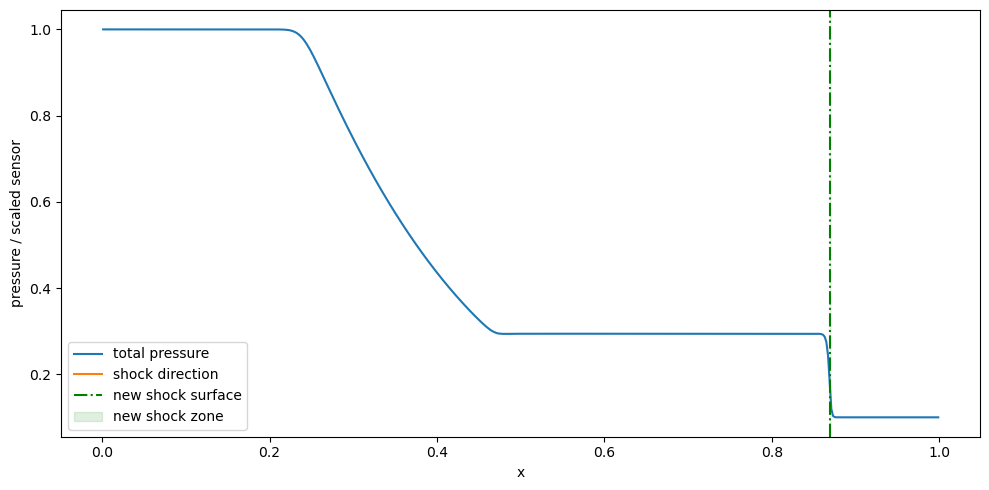

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(r, pressure, label="total pressure")

shock_dir_masked = jnp.where(new_result.shock_zones, new_result.shock_direction, jnp.nan)
plt.plot(r, shock_dir_masked, label="shock direction")

if new_surface_idx.size > 0:
    for idx in new_surface_idx:
        plt.axvline(
            r[idx], linestyle="-.", color="green",
            label="new shock surface" if idx == new_surface_idx[0] else None
        )

if new_zone_idx.size > 0:
    plt.axvspan(r[new_zone_idx[0]], r[new_zone_idx[-1]], alpha=0.12, color="green", label="new shock zone")

plt.xlabel("x")
plt.ylabel("pressure / scaled sensor")
plt.legend()
plt.tight_layout()

# Plot Density, Velocity, Entropy, and Pressure Profiles

Generate a multi-panel plot of density, velocity, entropy, and pressure, and annotate all panels with the detected shock surface locations.

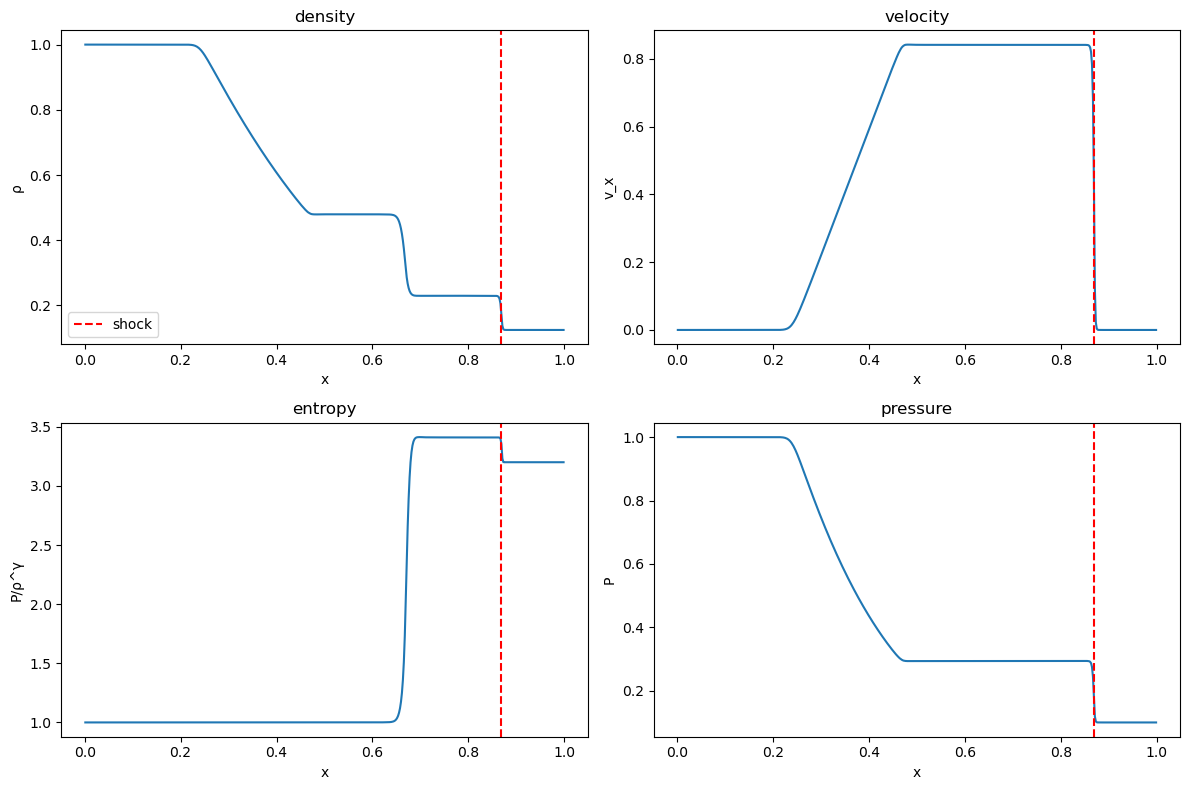

In [18]:
entropy = p_final / rho_final ** (5/3)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(r, rho_final)
axes[0, 0].set_title("density")
axes[0, 0].set_ylabel("ρ")

axes[0, 1].plot(r, u_final)
axes[0, 1].set_title("velocity")
axes[0, 1].set_ylabel("v_x")

axes[1, 0].plot(r, entropy)
axes[1, 0].set_title("entropy")
axes[1, 0].set_ylabel("P/ρ^γ")

axes[1, 1].plot(r, p_final)
axes[1, 1].set_title("pressure")
axes[1, 1].set_ylabel("P")

for ax in axes.flat:
    for idx in new_surface_idx:
        ax.axvline(r[idx], linestyle="--", color="red", label="shock")
    ax.set_xlabel("x")

axes[0, 0].legend()
plt.tight_layout()
plt.show()

# Debug Individual Shock Criteria

Import the internal shock-criterion helpers, compute each criterion separately, and plot them alongside pressure to diagnose how the shock finder behaves.

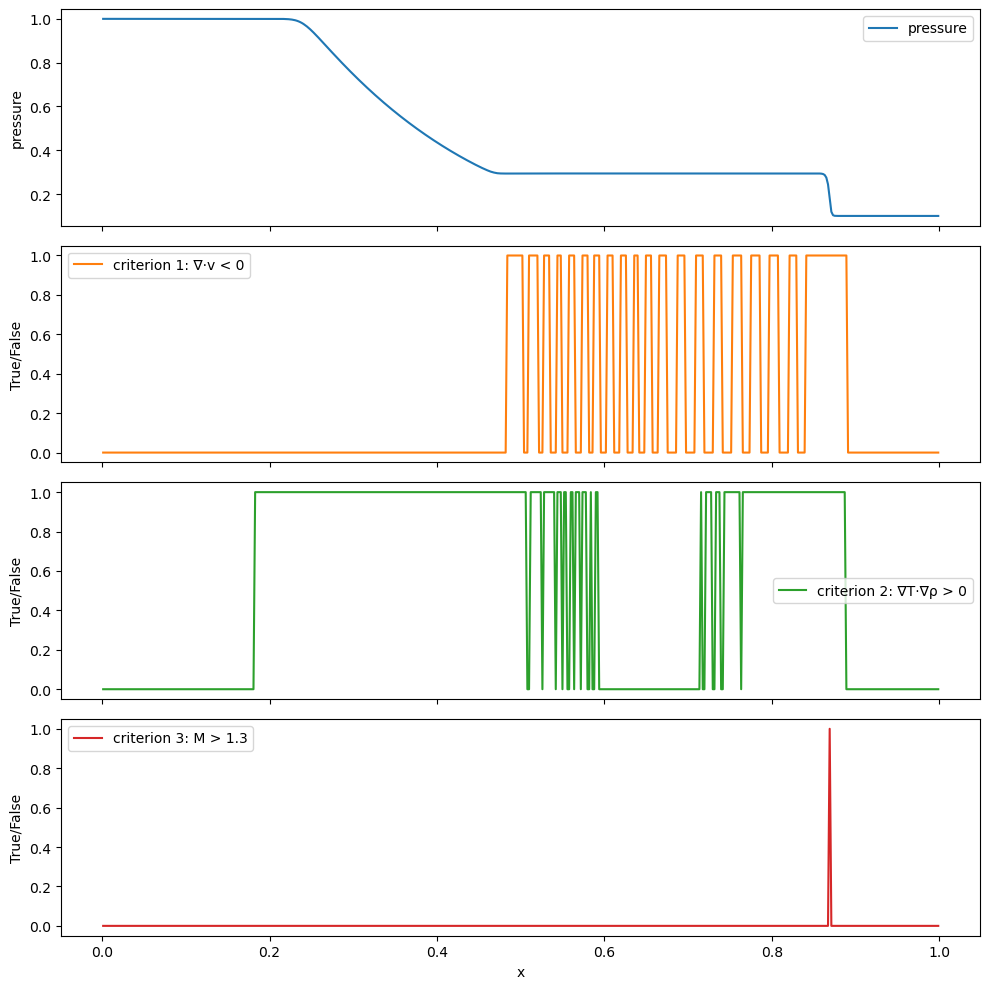

In [19]:
from astronomix.shock_finder.shock_finder_own import (
    _calculate_shock_direction,
    _shock_zone_criterion_converging_flow,
    _shock_zone_criterion_aligned_gradients,
    _shock_zone_criterion_minimum_mach,
)

r = helper_data.geometric_centers
pressure = final_state[registered_variables.pressure_index]
density = final_state[registered_variables.density_index]
velocity = final_state[registered_variables.velocity_index]

shock_direction = _calculate_shock_direction(pressure, density, config)

c1 = _shock_zone_criterion_converging_flow(velocity, config)
c2 = _shock_zone_criterion_aligned_gradients(pressure, density, config)
c3 = _shock_zone_criterion_minimum_mach(
    final_state,
    config,
    registered_variables,
    helper_data,
    shock_direction,
)

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
axes[0].plot(r, pressure, label="pressure")
axes[0].set_ylabel("pressure")
axes[0].legend()
axes[1].plot(r, c1.astype(float), color="tab:orange", label="criterion 1: ∇·v < 0")
axes[1].set_ylabel("True/False")
axes[1].legend()
axes[2].plot(r, c2.astype(float), color="tab:green", label="criterion 2: ∇T·∇ρ > 0")
axes[2].set_ylabel("True/False")
axes[2].legend()
axes[3].plot(r, c3.astype(float), color="tab:red", label="criterion 3: M > 1.3")
axes[3].set_ylabel("True/False")
axes[3].legend()
plt.xlabel("x")
plt.tight_layout()
plt.show()

# Result interpretation
## Step 1 — Understand the Sod shock tube

The Sod problem starts with two regions separated at x = 0.5:

```
left:  ρ=1.0, v=0, P=1.0   (high pressure)
right: ρ=0.125, v=0, P=0.1  (low pressure)
```

When released, three structures emerge and move rightward by t=0.2:

```
x:     0        0.2       0.5      0.65      0.87      1.0
       |---------|---------|--------|---------|---------|
S:     1.0      1.0→      1.0      3.4       3.2       3.2
                rarefaction        ^         ^
                (isentropic,       contact   shock
                S stays flat)      disc      (small
                                   (large    jump)
                                   jump,
                                   initial
                                   conditions)
```

```
x=0          0.2-0.5        0.67          0.87       1.0
|____________|______________|_____________|___________|
  undisturbed   rarefaction   contact disc   SHOCK    undisturbed
  left state    wave          (density jump) front    right state
```

Each structure has a distinct physical signature. Knowing where each one sits is your ground truth for evaluating the plots.

---

## Step 2 — Reading Image 1 (fluid state)

Go panel by panel and ask: **does this match what physics predicts for each structure?**

**Density (top left)**

```
x < 0.2  : ρ ≈ 1.0   → undisturbed left state           ✓
0.2-0.5  : ρ falling → rarefaction fan, smooth decrease  ✓
0.5-0.67 : ρ ≈ 0.47  → post-rarefaction plateau         ✓
0.67     : ρ drops   → contact discontinuity             ✓
0.67-0.87: ρ ≈ 0.22  → post-shock compressed gas        ✓
x > 0.87 : ρ ≈ 0.125 → undisturbed right state          ✓
```

The contact discontinuity at x≈0.67 is where density jumps but pressure does NOT jump — two fluids of different entropy in pressure equilibrium. The shock at x≈0.87 is where both density AND pressure jump.

**Velocity (top right)**

```
x < 0.2  : v = 0     → undisturbed, not yet reached      ✓
0.2-0.67 : v rising  → rarefaction accelerates gas       ✓
0.67-0.87: v ≈ 0.85  → uniform post-shock velocity       ✓
x > 0.87 : v = 0     → undisturbed right state           ✓
```

Key physical fact: velocity is **continuous across the contact discontinuity** (both sides move at the same speed) but **jumps sharply at the shock**. You can see both in the plot.

**Entropy (bottom left)**

```
x < 0.67 : S ≈ 1.0   → adiabatic process, no entropy change  ✓
x ≈ 0.67 : S jumps   → contact discontinuity, two fluids      ✓
0.67-0.87: S ≈ 3.4   → post-shock entropy rise               ✓
x > 0.87 : S ≈ 3.2   → right state entropy                   ✓
```

Key physical fact: **entropy only rises at shocks** (irreversible process). The rarefaction is isentropic (reversible), so entropy stays flat through it. If entropy rose in the rarefaction region that would be a serious bug. It does not — correct.

**Pressure (bottom right)**

```
x < 0.5  : P ≈ 1.0   → left plateau                    ✓
0.2-0.5  : P falling → rarefaction, smooth drop         ✓
0.5-0.87 : P ≈ 0.30  → post-shock pressure plateau      ✓
x > 0.87 : P ≈ 0.125 → undisturbed right state         ✓
```

Key physical fact: **pressure is continuous across the contact discontinuity** — only density jumps there, not pressure. You can verify: the pressure curve shows no feature at x≈0.67, only at x≈0.87. Correct.

**Red dashed line at x≈0.87**

This is where the shock finder placed the surface cell. It sits exactly at the sharp joint between the post-shock plateau and the undisturbed right state — correct in all four panels simultaneously. If it were misplaced onto the rarefaction or contact discontinuity that would be wrong.

---

## Step 3 — Reading Image 2 (the three criteria)

Now for each criterion ask: **where should it fire given what we just learned about the flow structure?**

**What you expect physically:**

| Region | ∇·v | ∇T·∇ρ | M > 1.3 |
|---|---|---|---|
| Undisturbed left | 0 | 0 | No |
| Rarefaction | negative (expanding) | depends | No |
| Contact disc x≈0.67 | ≈0 | could fire | No |
| Shock x≈0.87 | strongly negative | Yes | Yes |
| Undisturbed right | 0 | 0 | No |

**Criterion 1 — ∇·v < 0 (orange)**

Should fire: at the shock (strong compression) and possibly weakly at the rarefaction tail (gas is still accelerating, so some convergence).

Should NOT fire: broadly across the entire middle region with rapid oscillations.

What you see: rapid oscillation from x≈0.45 to x≈0.87. This is numerical noise — the HLLC solver leaves small velocity oscillations behind the rarefaction that the central difference picks up and amplifies. Each cell flips sign relative to its neighbor. **This is a red flag** — not physically wrong enough to break the final result (criterion 3 saves it) but indicates the gradient stencil is too sensitive.

**Criterion 2 — ∇T·∇ρ > 0 (green)**

Should fire: at the shock (both T and ρ jump in the same direction) and possibly at the contact discontinuity (ρ jumps but T may too slightly).

Should NOT fire: in the rarefaction interior, or oscillating rapidly.

What you see: fires at x≈0.2 (start of rarefaction — false positive), oscillates in the middle, then correctly fires near x≈0.87. The rarefaction hit is physically explainable — at the rarefaction head, both ρ and T start decreasing together so the dot product is positive. Technically not a shock but the criterion cannot distinguish it alone. Again criterion 3 saves it.

**Criterion 3 — M > 1.3 (red)**

Should fire: only at the shock, nowhere else. The rarefaction and contact discontinuity are subsonic processes. The Mach number is only super-1.3 at an actual shock.

What you see: fires at exactly one location near x≈0.87, zero everywhere else. **This is correct and clean.** This criterion is doing all the heavy lifting — it alone correctly localizes the shock.

---

## Step 4 — The key diagnostic question

When evaluating any shock finder output, ask these four questions in order:

**Q1: Does the shock surface land on the sharp discontinuity?**
Look at velocity and pressure — the shock is where both have a sharp jump (not a smooth ramp). The red line should sit there. ✓ here.

**Q2: Is the shock zone 3–4 cells wide, centered on the surface?**
The zone should be a compact band. If it spans 50 cells something is wrong with criterion 1 or 2. Here the oscillating criteria make this hard to judge from the individual panels, but the AND combination fixes it.

**Q3: Is the Mach number physically reasonable?**
For the Sod problem the exact solution gives M ≈ 1.75 at the shock. Your finder should return something close to that. Check `new_result.mach_numbers[new_result.shock_surface_cells]` against this.

**Q4: Are there false positives?**
Are any surface cells marked at the rarefaction (x≈0.2–0.5) or contact discontinuity (x≈0.67)? Those would be wrong. From Image 1 there is only one red line at x≈0.87 — no false positives. ✓

---

## Summary judgment

| | Correct? | Why |
|---|---|---|
| Shock location | ✓ | Sits on the sharp discontinuity |
| No false positives | ✓ | Only one surface cell |
| Criterion 3 | ✓ | Clean, fires only at shock |
| Criterion 1 | ⚠ | Noisy, but saved by criterion 3 |
| Criterion 2 | ⚠ | False positive at rarefaction head, saved by criterion 3 |
| Mach number | needs checking | Compare to exact M≈1.75 |

The final result is correct. The individual criteria are noisier than they should be, which is a robustness concern — if you ever run a case where criterion 3 is borderline (M just above 1.3), the noise in criteria 1 and 2 could cause false negatives at the real shock or false positives nearby.